In [25]:
from pathlib import Path
import pandas as pd

# The notebook lives in notebooks/ but the data lives in data/.
# This searches upward from the current folder until it finds
# data/heart_disease.csv, so the path works regardless of where
# the kernel's working directory happens to be.
def find_data_file(filename="heart_disease.csv"):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidate = parent / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find data/{filename} above {Path.cwd()}")

DATA_PATH = find_data_file()
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}  (rows, columns)")
df.head()

Shape: (303, 14)  (rows, columns)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [26]:
# Structure: column dtypes and how many non-null values each has.
df.info()

# Summary statistics for every column (count, mean, std, min, quartiles, max).
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [27]:
# Class balance of the target (proportions, not raw counts).
target_dist = df["target"].value_counts(normalize=True).sort_index()
print("Target distribution (proportion):")
print(target_dist.round(4))

print(f"\nClass 0 (no disease): {target_dist[0]:.1%}")
print(f"Class 1 (disease):    {target_dist[1]:.1%}")

Target distribution (proportion):
target
0    0.5413
1    0.4587
Name: proportion, dtype: float64

Class 0 (no disease): 54.1%
Class 1 (disease):    45.9%


In [28]:
# Missing values per column, and the total across the whole table.
missing_per_col = df.isna().sum()
print("Missing values per column:")
print(missing_per_col[missing_per_col > 0])   # show only columns that have any

print(f"\nTotal missing cells: {df.isna().sum().sum()}")
print(f"Rows with at least one missing value: {df.isna().any(axis=1).sum()}")

Missing values per column:
ca      4
thal    2
dtype: int64

Total missing cells: 6
Rows with at least one missing value: 6


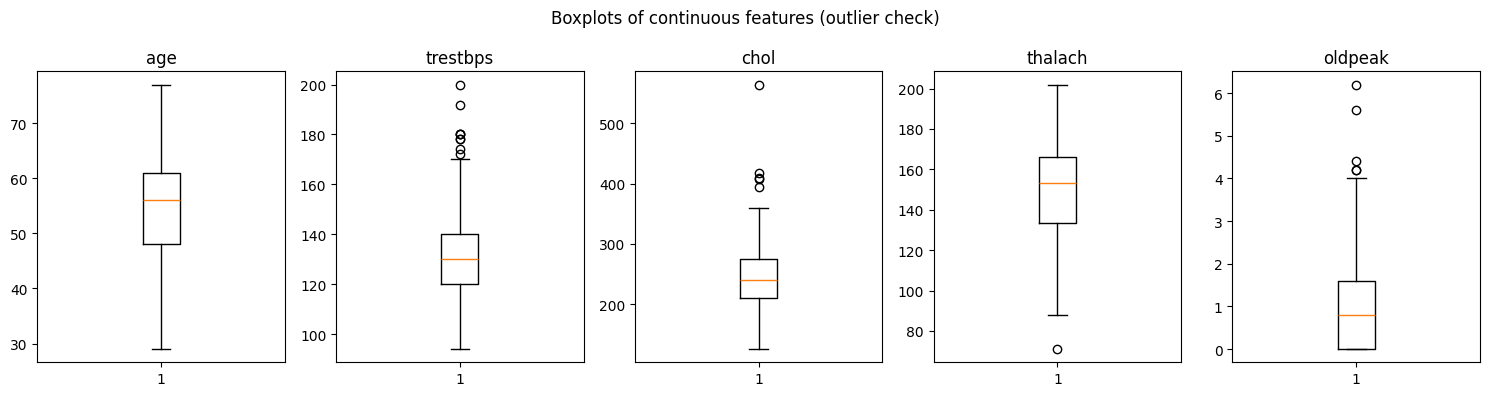

In [29]:
import matplotlib.pyplot as plt

# The 5 continuous features the spec calls out.
continuous = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, col in zip(axes, continuous):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.suptitle("Boxplots of continuous features (outlier check)")
plt.tight_layout()
plt.show()

In [30]:
# Duplicates and fully-empty columns.
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Fully-empty columns:  {[c for c in df.columns if df[c].isna().all()]}")

# Quantify outliers with the IQR rule for the continuous features.
print("\nOutliers per continuous feature (IQR rule):")
for col in ["age", "trestbps", "chol", "thalach", "oldpeak"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"  {col:9s}: {n_out:2d} outliers  (normal range [{low:.0f}, {high:.0f}])")

Exact duplicate rows: 0
Fully-empty columns:  []

Outliers per continuous feature (IQR rule):
  age      :  0 outliers  (normal range [28, 80])
  trestbps :  9 outliers  (normal range [90, 170])
  chol     :  5 outliers  (normal range [115, 371])
  thalach  :  1 outliers  (normal range [85, 215])
  oldpeak  :  5 outliers  (normal range [-2, 4])


In [31]:
import sys
import numpy as np
from sklearn.model_selection import train_test_split

# Make src/ importable from the notebook, then load our pipeline functions.
SRC_DIR = DATA_PATH.parent.parent / "src"
sys.path.insert(0, str(SRC_DIR))
from preprocessing import clean_data, split_features_target, build_preprocessor

# 1) Clean (dedup + empty cols) BEFORE the split -- these learn nothing.
df_clean = clean_data(df)
X, y = split_features_target(df_clean)

# 2) Split FIRST, then preprocess (the leakage-safe order).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"train: {X_train.shape}, test: {X_test.shape}")

# 3) Fit the preprocessor on TRAIN ONLY, then apply to both.
preprocessor = build_preprocessor()
preprocessor.fit(X_train)                     # learns medians + means/stds from TRAIN
X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)    # reuses TRAIN statistics

# 4) Sanity checks.
print("Missing after transform -> train:", np.isnan(X_train_t).sum(),
      "test:", np.isnan(X_test_t).sum())
print(f"TEST mean = {X_test_t.mean():.4f}  (not exactly 0 -> train stats reused, no leakage)")

train: (242, 13), test: (61, 13)
Missing after transform -> train: 0 test: 0
TEST mean = 0.0414  (not exactly 0 -> train stats reused, no leakage)


## EDA summary: what we found and how it shaped preprocessing

### What the EDA told us
- **Shape**: 303 rows, 13 features + 1 binary target. The original multiclass
  `num` was binarized to `target` and dropped to prevent label leakage.
- **Class balance**: 54% no-disease / 46% disease — fairly balanced, only mild imbalance.
- **Missing values**: only `ca` (4) and `thal` (2), 6 cells total (~2%); no other column is affected.
- **Outliers** (IQR rule): `trestbps` (9), `chol` (5), `oldpeak` (5), `thalach` (1); `age` has none.
- **No** duplicate rows and **no** fully-empty columns.

### How preprocessing was decided
- **Missing values → median imputation, not row deletion.** At inference we cannot
  drop a patient just because one value is missing, so imputation is the realistic
  choice. `ca` and `thal` are discrete codes, so the median is more meaningful than
  the mean and is robust to the outliers we found.
- **Outliers → kept, not removed.** Extreme values such as cholesterol 564 or resting
  BP 200 are clinically plausible high-risk patients; removing them would discard the
  most informative cases. We normalize their scale with `StandardScaler` instead.
- **Duplicates / empty columns → removed defensively** so the pipeline stays correct
  on new data, even though none are present now.
- **Leakage prevention**: the imputer and scaler learn from data, so they are fit on
  the **training split only** (split → fit on train → transform both). Structural
  cleaning (dedup, empty columns) learns nothing, so it is safe before the split.

### Implication for evaluation metrics
Because the task is clinical, **False Negatives (missing a real patient) are the most
costly error**. We prioritize **recall**, **balanced accuracy**, and **F1** over plain accuracy.